# MW test campaign: density evolution & disk projections

*First run a **base Milky Way** reference simulation and examine it in detail, then launch the parameter sweep and compare variants against that baseline.*

## What this notebook covers

| Stage | Tool | Output |
| --- | --- | --- |
| Base reference | `milky_way_disk_halo` (default params) | Baseline ρ(r), Σ(R), projections, ΔE/E₀ |
| Grid expansion | `galacticsics.campaign` | List of `(label, GalaxyModel)` variants |
| Solve + sample | Python `dbh` / diskdf; OpenMP C samplers (`sample.use_openmp`) | Equilibrium ICs per grid point |
| Evolve | ntropy tiered leapfrog | Self-gravitating N-body test |
| Analysis | `ntropy.analysis` | ρ(r), Σ(R), face-on / edge-on maps |

We use **`GalaxyModel.milky_way_disk_halo`** with a tunable DBH Poisson grid (`DBH_COARSE_GRID`, `DBH_DR`, `DBH_NR`, `DBH_LMAX` in the config cell). Production defaults are `nr=20000`, `lmax=6`, `dr=0.02` kpc; laptop screening uses `coarse_grid=True` (caps at `nr=4000`, `lmax≤4` for reliable `diskdf`). Sampling and N-body evolution at N ≈ 2×10⁵ add substantial time beyond `dbh`.

**Prerequisites:** `pip install -e ".[dev]"` and `pip install -e src/ntropy[dev]` (or `make install-dev` from the repo root). The editable install compiles the **OpenMP IC sampler** extension; restart the Jupyter kernel after installing. Legacy Fortran binaries are optional; the campaign uses the **Python physics backend** by default.

Figures and campaign outputs go to `notebooks/artifacts/campaign_walkthrough/` (gitignored).

## Campaign pipeline

All tunables live in **`notebooks/campaigns/mw_walkthrough.json`** (particles, DBH grid, ntropy evolve, force optimizations). The notebook loads that file and calls the campaign API — no scattered Python constants.

```
mw_walkthrough.json  →  run_campaign_from_config  →  solve → sample → evolve
                              ↓
                    {hash}/model.json, halo, disk, evolution/, rotation_curve_*.json
```

Each model gets a content-addressed work directory with `model.json`, particle files, `ntropy_config.json`, and manifest rows in `campaign_index.csv`.

**Units** (shared everywhere):

| Quantity | Unit |
| --- | --- |
| Length | kpc |
| Velocity | 100 km/s |
| Mass | 2.325×10⁹ M☉ |
| Time | 1 code unit ≈ 9.78 Myr ≈ **0.0098 Gyr** |
| G | 1 |

In [11]:
from __future__ import annotations

import copy
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

import importlib

from galacticsics.campaign import analysis as ca
importlib.reload(ca)
from galacticsics.campaign import run_config as rc
importlib.reload(rc)
from galacticsics.campaign.runner import run_campaign, run_campaign_from_config
from galacticsics.campaign.run_config import (
    build_type_registry,
    config_parameter_table,
    default_walkthrough_config,
    reload_walkthrough_context,
    sample_openmp_summary,
    save_walkthrough_config,
)
from galacticsics.campaign.spec import expand_grid
from ntropy.analysis.tiered_diagnostics import plot_tiered_diagnostics
from ntropy.integrations.galacticsics import galacticsics_available, require_galacticsics

REPO = Path.cwd()
if not (REPO / "src" / "galacticsics").exists():
    REPO = REPO.parent

CONFIG_PATH = REPO / "notebooks" / "campaigns" / "mw_walkthrough.json"

if not galacticsics_available():
    raise RuntimeError("Install galacticsics: pip install -e '.[dev]' from repo root")
require_galacticsics()

import sys

# Fast IC sampling needs the OpenMP C extension (built by editable install).
from galacticsics.sampling.openmp import extension_available, openmp_sampler_status, reload_extension
from galacticsics.sampling.sampler import SampleConfig

print(f"Python: {sys.executable}")
reload_extension()
status = openmp_sampler_status(SampleConfig(use_openmp=True))
print(f"IC sampler check: {status.log_label()}")
if not extension_available():
    print(
        "NOTE: OpenMP IC sampler extension not built — gendisk/genhalo will use slow Python path.\n"
        "      From repo root: make install-dev  (or pip install -e '.[dev]'), then Restart Kernel."
    )
else:
    print("OpenMP extension loaded. After code updates, always Restart Kernel before re-running sample.")

Python: /home/jbauer/GalactICSIsoWithGas/.venv/bin/python3
IC sampler check: OpenMP/all cores
OpenMP extension loaded. After code updates, always Restart Kernel before re-running sample.


## Configuration (edit in notebook — no JSON required)

The next cell defines **`CONFIG`** with every parameter and its default. Edit values directly, then run `apply_config()`.

| Block | What it controls |
| --- | --- |
| `particles` / `softening` | N-body IC counts and ε per component label |
| `sample` | IC sampler backend: `use_openmp` (fast C/OpenMP vs Python), `n_openmp_threads` (0 = all cores) |
| `base_model.grid` | DBH Poisson grid (`grid_dr`, `grid_nr`, `grid_lmax`) |
| `base_model.patch` | **Galaxy physics**: masses, scale lengths, halo v₀/a, disk kinematics |

Patch keys use dot paths (`disk.mass`, `halo.v0`, …). Units: kpc, 100 km/s, GalactICS mass units (≈ 2.325×10⁹ M☉). For parameter sweeps, use `base_model.grid.axes` or `campaigns/mw_grid.json`.

**OpenMP sampling:** `sample.use_openmp: true` is the default. The C extension is compiled on `pip install -e '.[dev]'` (or `make install-dev`). Restart the Jupyter kernel after installing so the extension loads.

Optional: `save_config()` writes to `mw_walkthrough.json`.

In [13]:
CONFIG = default_walkthrough_config()

# --- All parameters (defaults populated); edit any line, then apply_config() ---
CONFIG["name"] = "mw_walkthrough"
CONFIG["artifacts"]["root"] = "notebooks/artifacts/campaign_walkthrough"
CONFIG["run"]["skip_done"] = False
CONFIG["run"]["verbose"] = True
CONFIG["run"]["stages"] = ["solve", "sample", "evolve"]
CONFIG["run"]["reevolve_checkpoints"] = False
CONFIG["particles"]["disk"] = 250_000
CONFIG["particles"]["halo"] = 50_000
CONFIG["particles"]["bulge"] = 0
CONFIG["softening"]["disk"] = 0.1   # 10× legacy 0.01 kpc
CONFIG["softening"]["halo"] = 0.5   # 10× legacy 0.05 kpc
CONFIG["softening"]["bulge"] = 0.2  # 10× legacy 0.02 kpc
CONFIG["parallel"]["mpi_ranks"] = 1
CONFIG["parallel"]["core_fraction"] = 0.75
# Fast disk/halo ICs via OpenMP C extension (requires pip install -e '.[dev]', restart kernel)
CONFIG["sample"]["use_openmp"] = True
CONFIG["sample"]["n_openmp_threads"] = 0  # 0 = all logical cores
CONFIG["sample"]["run_diskdf"] = True
CONFIG["base_model"]["grid"]["name"] = "base_mw"
CONFIG["base_model"]["grid"]["base"] = "milky_way_disk_halo"
CONFIG["base_model"]["grid"]["axes"] = {}
CONFIG["base_model"]["grid"]["omit_components"] = [[]]
CONFIG["base_model"]["grid"]["coarse_grid"] = True
CONFIG["base_model"]["grid"].pop("grid_dr", None)
CONFIG["base_model"]["grid"].pop("grid_nr", None)
CONFIG["base_model"]["grid"].pop("grid_lmax", None)
CONFIG["base_model"]["grid"]["physics_backend"] = "python"
CONFIG["base_model"]["patch"]["halo.r_outer"] = 200.0
CONFIG["base_model"]["patch"]["halo.v0"] = 3.7
CONFIG["base_model"]["patch"]["halo.a"] = 33.0
CONFIG["base_model"]["patch"]["halo.dr_trunc"] = 12.0
CONFIG["base_model"]["patch"]["halo.cusp"] = 1.0
CONFIG["base_model"]["patch"]["disk.mass"] = 17.0
CONFIG["base_model"]["patch"]["disk.scale_length"] = 2.5
CONFIG["base_model"]["patch"]["disk.outer_radius"] = 20.25
CONFIG["base_model"]["patch"]["disk.scale_height"] = 0.25
CONFIG["base_model"]["patch"]["disk.trunc_width"] = 3.0
CONFIG["base_model"]["patch"]["disk.hole_radius"] = 0.0
CONFIG["base_model"]["patch"]["disk.core_radius"] = 1.5
CONFIG["base_model"]["patch"]["disk_kinematics.sigma_r0"] = 0.85
CONFIG["base_model"]["patch"]["disk_kinematics.sigma_r_scale"] = 2.8
CONFIG["base_model"]["patch"]["disk_kinematics.n_radial_steps"] = 50
CONFIG["base_model"]["patch"]["disk_kinematics.n_iterations"] = 10
CONFIG["base_model"]["patch"]["disk_kinematics.toomre_q_target"] = 1.5
CONFIG["base_model"]["patch"]["black_hole.mass"] = 0.0
CONFIG["sweep"]["enabled"] = False
CONFIG["sweep"]["grid_spec"] = "campaigns/mw_grid.json"
CONFIG["evolve"]["end_time_gyr"] = 0.5
CONFIG["evolve"]["dt_base"] = 0.05
CONFIG["evolve"]["timestep_eta"] = 0.025
CONFIG["evolve"]["max_timestep_bin"] = 7  # screening; use ≤5 for tighter |ΔE/E₀|
CONFIG["evolve"]["timestep_update_every"] = 2
CONFIG["evolve"]["integrator_order"] = 2
CONFIG["evolve"]["diagnostics_every"] = 20
CONFIG["evolve"]["particle_dump_every"] = 100
CONFIG["force"]["theta"] = 0.75
CONFIG["force"]["rebuild_every"] = 10
CONFIG["force"]["active_subset"] = True
CONFIG["force"]["bh_optimizations_preset"] = "optimized"
CONFIG["force"]["bh_optimizations"]["preset"] = "optimized"
CONFIG["force"]["bh_optimizations"]["simd_leaves"] = True
CONFIG["force"]["bh_optimizations"]["omp_schedule"] = "guided"
CONFIG["checkpoints_gyr"] = [0.0, 0.05, 0.1]


def save_config() -> None:
    save_walkthrough_config(CONFIG_PATH, CONFIG)
    print(f"Saved → {CONFIG_PATH}")


def apply_config():
    global CFG, BUDGET, BASE_SPEC, BASE_ROOT, CAMPAIGN_ROOT, CHECKPOINT_GYR
    global REEVOLVE_FOR_CHECKPOINTS, RUN_KW, END_TIME_GYR, SKIP_DONE, SWEEP_SPEC, registry, ARTIFACTS
    CFG, BUDGET = reload_walkthrough_context(CONFIG_PATH, raw=CONFIG, repo=REPO)
    BASE_SPEC = CFG.base_grid
    BASE_ROOT = CFG.paths.base_root
    CAMPAIGN_ROOT = CFG.paths.sweep_root
    ARTIFACTS = CFG.paths.artifacts
    ARTIFACTS.mkdir(parents=True, exist_ok=True)
    CHECKPOINT_GYR = CFG.checkpoints_gyr
    REEVOLVE_FOR_CHECKPOINTS = bool(CFG.run.get("reevolve_checkpoints", False))
    RUN_KW = CFG.run_campaign_kwargs()
    END_TIME_GYR = float(CFG.evolve.get("end_time_gyr", 1.0))
    SKIP_DONE = bool(CFG.run.get("skip_done", True))
    SWEEP_SPEC = CFG.sweep_grid()
    registry = build_type_registry(CONFIG)
    print(sample_openmp_summary(CONFIG))
    return CFG


from galacticsics.campaign.spec import model_component_parameter_table

apply_config()
display(config_parameter_table(CONFIG))
print()
for line in CFG.summary_lines():
    print(line)
print()
_, preview_model = CFG.base_model()
display(model_component_parameter_table(preview_model))

Sample: OpenMP C samplers (all cores)


,parameter,value
0,artifacts.root,notebooks/artifacts/campaign_walkthrough
1,base_model.grid.axes,{}
2,base_model.grid.base,milky_way_disk_halo
3,base_model.grid.coarse_grid,True
4,base_model.grid.name,base_mw
...,...,...
59,solve.n_workers,0
60,solve.nint,20
61,solve.npsi,1000
62,sweep.enabled,False



Config: mw_walkthrough.json
Particles: disk=250,000, halo=50,000 (total 300,000)
Softening ε [kpc]: bulge=0.2, disk=0.1, halo=0.5
Evolve: 0.5 Gyr | verbose: True
Tiered timestep:
  dt_base     : 0.05000 code (0.489 Myr, bin 0)
  dt_max      : 6.4000 code (62.59 Myr, bin 7)
  eta         : 0.025
  bin update  : every 2 fine substep(s)
  integrator  : order-2 leapfrog
  duration    : 0.5 Gyr = 51.12 code units in 1022 fine substeps
DBH grid: dr=0.05 kpc, nr=4000, lmax=4 (r_max ≈ 200 kpc; cost scales ~ nr × lmax²)
Force: theta=0.75, rebuild_every=10, active_subset=True, bh=optimized
Parallel: 8 cores → budget 6 (MPI 1 × OMP 6 = 6)
Sample: OpenMP C samplers (all cores)
Artifacts → /home/jbauer/GalactICSIsoWithGas/notebooks/artifacts/campaign_walkthrough
Model patch: {'halo.r_outer': 200.0, 'halo.v0': 3.7, 'halo.a': 33.0, 'halo.dr_trunc': 12.0, 'halo.cusp': 1.0, 'disk.mass': 17.0, 'disk.scale_length': 2.5, 'disk.outer_radius': 20.25, 'disk.scale_height': 0.25, 'disk.trunc_width': 3.0, 'dis

,parameter,value,enabled
0,halo.r_outer,200.00,True
1,halo.v0,3.70,True
2,halo.a,33.00,True
3,halo.dr_trunc,12.00,True
4,halo.cusp,1.00,True
5,disk.mass,17.00,True
6,disk.scale_length,2.50,True
7,disk.outer_radius,20.25,True
8,disk.scale_height,0.25,True
9,disk.trunc_width,3.00,True


## 1. Base Milky Way simulation (reference case)

Run the default `milky_way_disk_halo` model using settings from `mw_walkthrough.json`:

- Edit **`notebooks/campaigns/mw_walkthrough.json`** to change particles, DBH grid, Toomre Q, evolve duration, or force knobs
- `run_campaign_from_config` writes `ntropy_config.json` per model (tiered leapfrog, optimized `bh_c`, active-subset forces)

Outputs land in `base_mw/{hash}/`.

In [14]:
# Analysis helpers (plot_density_map uses percentile contrast for projections)
import importlib

importlib.reload(ca)

from ntropy.analysis.density import compare_density_profiles
from ntropy.analysis.disk_density import compare_surface_profiles
from ntropy.softening import kinetic_energy, total_energy

from galacticsics.campaign.benchmarks import diagnose_ic_stability, explain_ic_instability, ic_looks_stable
from galacticsics.campaign.analysis import load_ic_state

load_merged_state = ca.load_merged_state
load_evolved_state = ca.load_evolved_state
halo_spherical_profile = ca.halo_spherical_profile
halo_profile_bin_edges = ca.halo_profile_bin_edges
halo_projections = ca.halo_projections
plot_halo_spherical_profile = ca.plot_halo_spherical_profile
HALO_PROFILE_MIN_COUNT = ca.HALO_PROFILE_MIN_COUNT
disk_surface_profile = ca.disk_surface_profile
disk_projections = ca.disk_projections
load_run_diagnostics = ca.load_run_diagnostics
model_summary_table = ca.model_summary_table
density_drift_metrics = ca.density_drift_metrics
analytic_halo_overlay = ca.analytic_halo_overlay
load_rotation_curve = ca.load_rotation_curve
plot_density_map = ca.plot_density_map
density_map_color_limits = ca.density_map_color_limits
add_density_colorbar = ca.add_density_colorbar

### 1a. Run solve → sample → evolve for the base model

In [ ]:
base_label, BASE_MODEL = CFG.base_model()
display(model_summary_table(BASE_MODEL))

base_manifest = run_campaign_from_config(
    CONFIG_PATH, work_root=BASE_ROOT, grid_spec=BASE_SPEC, raw=CONFIG, repo=REPO
)

base_row = base_manifest.rows[0]
BASE_WORK_DIR = Path(base_row["path"])
print(f"Base model: {base_label}")
print(f"Work dir: {BASE_WORK_DIR}")
if "toomre_q" in base_row:
    print(f"Toomre Q (2.5 R_d): {base_row['toomre_q']:.3f}")
pd.DataFrame([base_row])

,parameter,value
0,halo.r_outer,200.00
1,halo.v0,3.70
2,halo.a,33.00
3,disk.mass,17.00
4,disk.scale_length,2.50
5,disk.scale_height,0.25
6,disk_kinematics.sigma_r0,0.85
7,disk_kinematics.toomre_q_target,1.50
8,grid.nr,4000.00
9,grid.lmax,4.00


[15:30:08] ========================================================================
[15:30:08] Campaign 'base_mw' → /home/jbauer/GalactICSIsoWithGas/notebooks/artifacts/campaign_walkthrough/base_mw
[15:30:08] Stages: solve, sample, evolve | models: 1
[15:30:08]   particles: disk=250,000, halo=50,000
[15:30:08]   end_time_gyr: 0.5
[15:30:08]   dt_base: 0.05
[15:30:08]   mpi_ranks: 1
[15:30:08]   core_fraction: 0.75
[15:30:08]   bh_optimizations: optimized
[15:30:08]   force_theta: 0.75
[15:30:08]   force_active_subset: True
[15:30:08]   force_rebuild_every: 10
[15:30:08]   softening_kpc: {'disk': 0.1, 'halo': 0.5, 'bulge': 0.2}
[15:30:08]   diagnostics_every: 20
[15:30:08]   skip_done: False
[15:30:08]   physics_backend: python
[15:30:08] ========================================================================
[15:30:08] ------------------------------------------------------------------------
[15:30:08] Model [1/1] full  hash=c8c47a84e4cc…
  dir: /home/jbauer/GalactICSIsoWithGas/noteboo

full:   0%|          | 0/3 [00:00<?, ?stage/s]

[15:30:08] ▶ solve — dbh (nr=4000, lmax=4)
[15:30:08]   legacy: dbh (python)  (cwd=/home/jbauer/GalactICSIsoWithGas/notebooks/artifacts/campaign_walkthrough/base_mw/c8c47a84e4cc)
[15:32:38]   ✓ solve finished in 2.5m | rtidal=200 | solve_seconds=148.4
[15:32:38] ▶ sample — disk=250,000, halo=50,000
[15:32:38]   IC sampler: OpenMP/all cores
[15:32:38]   legacy: diskdf [python]  (cwd=/home/jbauer/GalactICSIsoWithGas/notebooks/artifacts/campaign_walkthrough/base_mw/c8c47a84e4cc)
[15:32:38] Toomre Q = 1.5000 at R = 6.250 kpc (sigma_r0 = 1.1810, sigma_r_scale = 2.800 kpc); target Q = 1.5000
[15:32:54]   legacy: gendisk [OpenMP/all cores]  (cwd=/home/jbauer/GalactICSIsoWithGas/notebooks/artifacts/campaign_walkthrough/base_mw/c8c47a84e4cc)
[15:32:58]   gendisk: 250,000/250,000 particles (OpenMP)
[15:33:00]   legacy: genhalo [OpenMP/all cores]  (cwd=/home/jbauer/GalactICSIsoWithGas/notebooks/artifacts/campaign_walkthrough/base_mw/c8c47a84e4cc)
[15:33:00]   genhalo: 50,000/50,000 particles (Ope

=== full evolve ===
  integrator : tiered_leapfrog, order=2
  dt_base    : 0.05000 code units
  end_time   : 0.5 Gyr
  n_substeps : 1022 (fine, global clock)
  duration   : 0.5 Gyr = 51.12 code units in 1022 fine substeps (dt_base=0.05000)
  force      : bh_c (theta=0.75)
  parallel   : off
  seed       : 42
[ntropy] full evolve: N=300,000, 1022 fine substeps → 0.5 Gyr (dt_base=0.05000)
[ntropy] initial force evaluation…
step    0/1022 | t=0.0000 Gyr | active 100.0% (300000) | dE/E0=0.00e+00 | bins 255833,23423,20741,3,0,0,0,0 | disk μb=0.0 halo μb=1.3
[ntropy] integrating…


### 1b. Detailed base-case diagnostics

Particle counts, halo ρ(r) and disk Σ(R) at t=0 vs t=`END_TIME_GYR`, disk face-on / edge-on projections, and energy drift. These plots are the reference against which grid variants should be compared.

**Reading the plots:** halo profiles use `r ≥ 1 kpc` and shells with ≥20 particles (sparse inner log bins are omitted). Face-on / edge-on maps share one color scale per row so time slices are directly comparable. Screening settings (N≈10⁴–10⁵, 0.5 Gyr, tiered `dt_max` bin 7) often show |ΔE/E₀|≳0.1 and large ρ/Σ drift — that is genuine N-body heating, not a plotting bug. For tighter evolution use shorter `end_time_gyr`, lower `max_timestep_bin`, or production N.

In [10]:
from galacticsics.campaign.benchmarks import invalidate_ic_artifacts
from galacticsics.campaign.spec import format_dbh_grid_summary


def _load_base_states():
    initial = load_merged_state(BASE_WORK_DIR)
    final = load_evolved_state(BASE_WORK_DIR, initial)
    return initial, final


def _ensure_stable_base_ics(*, retries: int = 1):
    """Re-run solve→sample→evolve when skip_done left stale cordbh / particle files."""
    global base_initial, base_final, base_row, base_manifest

    base_initial, base_final = _load_base_states()
    ic_diag = diagnose_ic_stability(base_initial)
    print(f"IC velocity check: {ic_diag}")
    if ic_looks_stable(base_initial):
        return ic_diag

    if retries < 1:
        base_model = ca.load_model_json(BASE_WORK_DIR)
        raise RuntimeError(
            f"Disk IC velocities look unstable: {explain_ic_instability(state=base_initial)}\n"
            f"diag={ic_diag}\n"
            f"{format_dbh_grid_summary(base_model)}\n"
            "Re-run solve→sample with skip_done=False (stale cordbh.dat is a common cause). "
            "With coarse_grid=True keep lmax≤4; use coarse_grid=False for production lmax=6 solves."
        )

    removed = invalidate_ic_artifacts(BASE_WORK_DIR)
    print(
        "Unstable ICs detected — re-running solve→sample→evolve "
        f"(removed {', '.join(removed) or 'no cached files'})"
    )
    saved_skip = CONFIG["run"]["skip_done"]
    CONFIG["run"]["skip_done"] = False
    apply_config()
    base_manifest = run_campaign_from_config(
        CONFIG_PATH, work_root=BASE_ROOT, grid_spec=BASE_SPEC, raw=CONFIG, repo=REPO
    )
    base_row = base_manifest.rows[0]
    CONFIG["run"]["skip_done"] = saved_skip
    return _ensure_stable_base_ics(retries=retries - 1)


ic_diag = _ensure_stable_base_ics(retries=1)
base_final = load_evolved_state(BASE_WORK_DIR, base_initial)
if base_final is None:
    raise FileNotFoundError("Base evolve stage did not write evolution/final.dat")

print(f"N = {base_initial.n:,} particles")
for label in registry.types:
    mask = base_initial.tags == label
    if np.any(mask):
        print(f"  {label:5s}: {mask.sum():6,d}")

# total_energy uses kinetic-only for N > 16k (see ntropy.softening.LARGE_N_ENERGY_THRESHOLD)
e0 = total_energy(base_initial.pos, base_initial.vel, base_initial.mass, base_initial.eps)
ef = total_energy(base_final.pos, base_final.vel, base_final.mass, base_final.eps)
base_dE = abs(ef - e0) / max(abs(e0), 1e-30)
print(f"|ΔE/E₀| after {END_TIME_GYR} Gyr: {base_dE:.3e} (KE proxy at N={base_initial.n:,})")
if "dE_over_E0" in base_row:
    print(f"Campaign-reported |ΔE/E₀|: {base_row['dE_over_E0']:.3e}")

# --- profiles: initial vs final (shared halo shell edges) ---
halo_edges = halo_profile_bin_edges()
halo_i = halo_spherical_profile(base_initial, bin_edges=halo_edges)
halo_f = halo_spherical_profile(base_final, bin_edges=halo_edges)
disk_i = disk_surface_profile(base_initial)
disk_f = disk_surface_profile(base_final)
halo_drift = compare_density_profiles(halo_i, halo_f, min_count=HALO_PROFILE_MIN_COUNT)
disk_drift = compare_surface_profiles(disk_i, disk_f, min_count=20)
print(f"Max relative halo ρ drift: {halo_drift:.3f}")
print(f"Max relative disk Σ drift: {disk_drift:.3f}")

DISK_PROFILE_MIN_COUNT = 20
if base_dE > 0.12 or halo_drift > 0.75 or disk_drift > 0.75:
    print(
        "⚠ Evolution looks heated for screening settings "
        f"(|ΔE/E₀|={base_dE:.3f}, halo ρ drift={halo_drift:.2f}, disk Σ drift={disk_drift:.2f}). "
        "Try shorter end_time_gyr, max_timestep_bin≤5, or higher N before interpreting morphology."
    )

base_model = ca.load_model_json(BASE_WORK_DIR)

fig, axes = plt.subplots(3, 2, figsize=(12, 13), constrained_layout=True)

plot_halo_spherical_profile(
    axes[0, 0],
    halo_i,
    halo_f,
    model=base_model,
    end_time_gyr=END_TIME_GYR,
    min_count=HALO_PROFILE_MIN_COUNT,
)

vi, vf = disk_i.counts >= DISK_PROFILE_MIN_COUNT, disk_f.counts >= DISK_PROFILE_MIN_COUNT
axes[0, 1].semilogy(disk_i.r_mid[vi], disk_i.sigma[vi], "C0-", label="t=0", ms=3)
axes[0, 1].semilogy(disk_f.r_mid[vf], disk_f.sigma[vf], "C1--", label=f"t={END_TIME_GYR} Gyr", ms=3)
axes[0, 1].set_xlabel("R [kpc]")
axes[0, 1].set_ylabel("Σ [M_unit / kpc²]")
axes[0, 1].set_title("Disk Σ(R)")
axes[0, 1].legend(fontsize=8)

halo_face_i, halo_edge_i = halo_projections(base_initial)
halo_face_f, halo_edge_f = halo_projections(base_final)
halo_vmin, halo_vmax = density_map_color_limits(
    halo_face_i, halo_face_f, halo_edge_i, halo_edge_f
)

im_hf0 = plot_density_map(
    axes[1, 0], halo_face_i, title="Halo face-on t=0", vmin=halo_vmin, vmax=halo_vmax
)
im_hf1 = plot_density_map(
    axes[1, 1],
    halo_face_f,
    title=f"Halo face-on t={END_TIME_GYR} Gyr",
    vmin=halo_vmin,
    vmax=halo_vmax,
)
for ax in axes[1, :]:
    ax.set_xlabel("x [kpc]")
axes[1, 0].set_ylabel("y [kpc]")
add_density_colorbar(fig, im_hf1, axes[1, :], label="log₁₀ ρ")

im_he0 = plot_density_map(
    axes[2, 0],
    halo_edge_i,
    title="Halo edge-on t=0 (|z| < 0.3 kpc)",
    vmin=halo_vmin,
    vmax=halo_vmax,
)
im_he1 = plot_density_map(
    axes[2, 1],
    halo_edge_f,
    title=f"Halo edge-on t={END_TIME_GYR} Gyr",
    vmin=halo_vmin,
    vmax=halo_vmax,
)
for ax in axes[2, :]:
    ax.set_xlabel("x [kpc]")
axes[2, 0].set_ylabel("z [kpc]")
add_density_colorbar(fig, im_he1, axes[2, :], label="log₁₀ ρ")

fig.suptitle("Base Milky Way — density structure", y=1.01)
base_profile_path = ARTIFACTS / "base_density_diagnostics.png"
fig.savefig(base_profile_path, dpi=150, bbox_inches="tight")
plt.show()

# --- disk projections (separate figure) ---
face_i, edge_i = disk_projections(base_initial)
face_f, edge_f = disk_projections(base_final)
fig, axes = plt.subplots(2, 2, figsize=(11, 9), constrained_layout=True)
face_vmin, face_vmax = density_map_color_limits(face_i, face_f)
edge_vmin, edge_vmax = density_map_color_limits(edge_i, edge_f)
im0 = plot_density_map(axes[0, 0], face_i, title="Disk face-on t=0", vmin=face_vmin, vmax=face_vmax)
im1 = plot_density_map(
    axes[0, 1], face_f, title=f"Disk face-on t={END_TIME_GYR} Gyr", vmin=face_vmin, vmax=face_vmax
)
for ax in axes[0, :]:
    ax.set_xlabel("x [kpc]")
axes[0, 0].set_ylabel("y [kpc]")
add_density_colorbar(fig, im1, axes[0, :], label="log₁₀ Σ")

plot_density_map(
    axes[1, 0], edge_i, title="Disk edge-on t=0 (|z| < 0.3 kpc)", vmin=edge_vmin, vmax=edge_vmax
)
im3 = plot_density_map(
    axes[1, 1], edge_f, title=f"Disk edge-on t={END_TIME_GYR} Gyr", vmin=edge_vmin, vmax=edge_vmax
)
for ax in axes[1, :]:
    ax.set_xlabel("x [kpc]")
axes[1, 0].set_ylabel("z [kpc]")
add_density_colorbar(fig, im3, axes[1, :], label="log₁₀ Σ")

disk_proj_path = ARTIFACTS / "base_disk_projections.png"
fig.savefig(disk_proj_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved {base_profile_path.name}, {disk_proj_path.name}")

IC velocity check: {'r_max': 237.85685258729376, 'disk_v_max': 4.586307027474589, 'disk_v_median': 1.3449250054502628, 'halo_v_max': 5.547744211044183, 'halo_v_median': 1.9541748325756507}
N = 100,000 particles
  halo : 50,000
  disk : 50,000
|ΔE/E₀| after 0.5 Gyr: 2.021e-01 (KE proxy at N=100,000)
Campaign-reported |ΔE/E₀|: 2.021e-01


NameError: name 'halo_profile_bin_edges' is not defined

### 1c. ntropy bin / activity diagnostics (per fine step)

Each tiered leapfrog run writes:

- `evolution/diagnostics.csv` — energy drift, active fraction, global bin histogram, per-type mean bin **every fine substep**
- `evolution/particles/step_XXXXXX.npz` — per-particle `timestep_bin`, `type_id`, `accel_mag`, positions (every `PARTICLE_DUMP_EVERY` steps)

Re-run with `SKIP_DONE = False` if these files are missing from an older evolve stage.

53 diagnostic records, t = 0 … 0.4998 Gyr


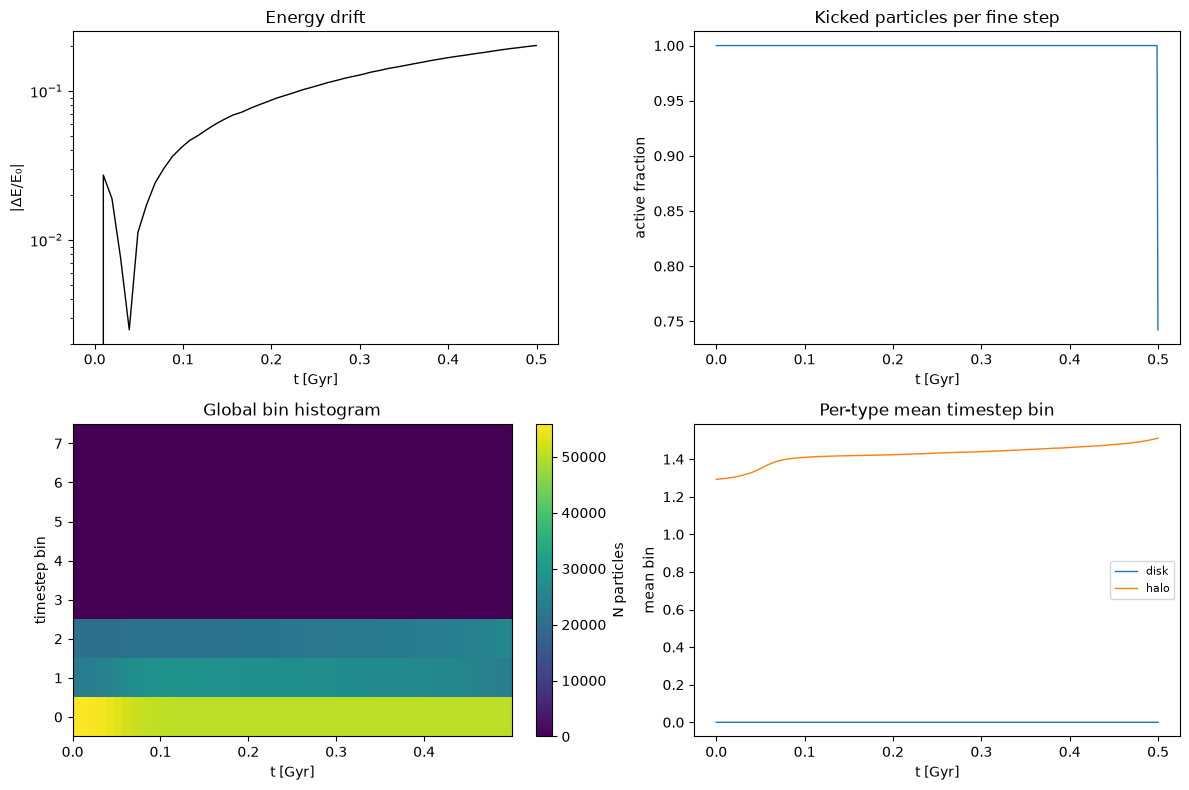

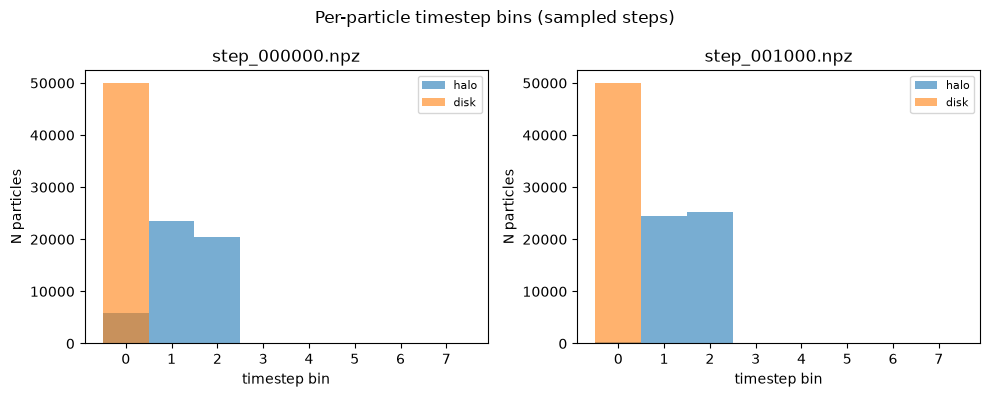

Saved base_ntropy_diagnostics.png


In [6]:
base_diag_dir = BASE_WORK_DIR / "evolution"
if not (base_diag_dir / "diagnostics.csv").exists():
    raise FileNotFoundError(
        f"Missing {base_diag_dir / 'diagnostics.csv'} — re-run base evolve with SKIP_DONE=False"
    )

base_diag_df, _ = load_run_diagnostics(BASE_WORK_DIR)
print(f"{len(base_diag_df)} diagnostic records, t = 0 … {base_diag_df.t_gyr.iloc[-1]:.4f} Gyr")

fig = plot_tiered_diagnostics(base_diag_df)
diag_fig_path = ARTIFACTS / "base_ntropy_diagnostics.png"
fig.savefig(diag_fig_path, dpi=150, bbox_inches="tight")
plt.show()

particle_dir = base_diag_dir / "particles"
npz_files = sorted(particle_dir.glob("step_*.npz"))
if npz_files:
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    for ax, path in zip(axes, [npz_files[0], npz_files[-1]]):
        data = np.load(path)
        bins = data["timestep_bin"]
        type_id = data["type_id"]
        for tid, label, color in [(1, "halo", "C0"), (3, "disk", "C1")]:
            mask = type_id == tid
            if np.any(mask):
                ax.hist(bins[mask], bins=np.arange(-0.5, 8.5, 1), alpha=0.6, label=label, color=color)
        ax.set_xlabel("timestep bin")
        ax.set_ylabel("N particles")
        ax.set_title(path.name)
        ax.legend(fontsize=8)
    fig.suptitle("Per-particle timestep bins (sampled steps)")
    fig.tight_layout()
    plt.show()
else:
    print("No particle bin dumps in", particle_dir)
print(f"Saved {diag_fig_path.name}")

## 2. Define and inspect the parameter sweep

Mini grid (two halo circular velocities) based on `campaigns/mw_grid.json`, using the same DBH grid knobs as the base case (`DBH_COARSE_GRID`, `DBH_NR`, etc.).

Compare sweep outputs in later sections against the **base reference** in `BASE_WORK_DIR`.

In [7]:
SWEEP_SPEC = CFG.sweep_grid()
if SWEEP_SPEC is None:
    print("Sweep disabled in mw_walkthrough.json (set sweep.enabled=true to run)")
else:
    grid_models = expand_grid(SWEEP_SPEC)
    grid_df = pd.DataFrame(
        {
            "label": [label for label, _ in grid_models],
            "halo_v0": [m.halo.v0 if m.halo else None for _, m in grid_models],
            "disk_mass": [m.disk.mass if m.disk else None for _, m in grid_models],
            "grid_nr": [m.grid.nr for _, m in grid_models],
        }
    )
    display(grid_df)

Sweep disabled in mw_walkthrough.json (set sweep.enabled=true to run)


## 3. Run the parameter sweep (solve → sample → evolve)

After validating the base case, run the mini halo-velocity sweep with the same pipeline as section 1:

1. **solve** — Python self-consistent `dbh` (disk + halo)
2. **sample** — OpenMP C disk/halo samplers when `sample.use_openmp` and extension built (`N_DISK` + `N_HALO`)
3. **evolve** — ntropy tiered leapfrog to `END_TIME_GYR` (`MPI_RANKS=2` by default, `CORE_FRACTION=0.75`)

Set `SKIP_DONE = False` or delete `CAMPAIGN_ROOT` to re-run sweep points after config changes. The manifest (`campaign_index.csv`) records wall times and |ΔE/E₀|. With `VERBOSE_CAMPAIGN = True` (default), `run_campaign` prints timestamped stage logs and tails ntropy evolve lines (also written to `evolution/diagnostics.progress.jsonl`).

In [8]:
if SWEEP_SPEC is None:
    manifest_df = pd.DataFrame()
else:
    sweep_kw = CFG.run_campaign_kwargs()
    sweep_extra = sweep_kw.pop("bh_optimizations_extra", None)
    manifest = run_campaign(
        SWEEP_SPEC,
        CAMPAIGN_ROOT,
        bh_optimizations_extra=sweep_extra,
        **sweep_kw,
    )
    manifest_df = pd.DataFrame(manifest.rows)
manifest_df

""


## 4. Load a sweep point for detailed analysis

Pick one grid point (default: first row) and reload its ICs and evolved state. The analysis below mirrors section 1b for a single sweep variant.

In [9]:
EXAMPLE_IDX = 0
example = manifest_df.iloc[EXAMPLE_IDX]
work_dir = Path(example["path"])
print(f"Sweep model: {example['label']}\nWork dir: {work_dir}")
print(f"Base reference: {BASE_WORK_DIR}")

initial_state = load_merged_state(work_dir)
final_state = load_evolved_state(work_dir, initial_state)

print(f"N = {initial_state.n:,} particles")
for label in registry.types:
    mask = initial_state.tags == label
    if np.any(mask):
        print(f"  {label:5s}: {mask.sum():6,d}")

IndexError: single positional indexer is out-of-bounds

### 4a. Sweep point — initial density and disk projections (t = 0)

In [ ]:
halo_init = halo_spherical_profile(initial_state)
disk_init = disk_surface_profile(initial_state)
face_init, edge_init = disk_projections(initial_state)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].loglog(halo_init.r_mid[halo_init.counts > 0], halo_init.rho[halo_init.counts > 0], "o-", ms=4)
axes[0].set_xlabel("r [kpc]")
axes[0].set_ylabel("ρ [M_unit / kpc³]")
axes[0].set_title(f"Halo ρ(r) — {example['label']} (t=0)")

axes[1].semilogy(disk_init.r_mid[disk_init.counts > 0], disk_init.sigma[disk_init.counts > 0], "o-", ms=4)
axes[1].set_xlabel("R [kpc]")
axes[1].set_ylabel("Σ [M_unit / kpc²]")
axes[1].set_title("Disk Σ(R) — t=0")

im = plot_density_map(axes[2], face_init, title="Disk face-on (log Σ)")
axes[2].set_xlabel("x [kpc]")
axes[2].set_ylabel("y [kpc]")
fig.colorbar(im, ax=axes[2], fraction=0.046, label="log₁₀ Σ")
fig.tight_layout()
init_path = ARTIFACTS / "sweep_initial_density.png"
fig.savefig(init_path, dpi=150)
plt.show()
print(f"Saved {init_path.name}")

### 4b. Edge-on disk projections (sweep point, t = 0)

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
proj_vmin, proj_vmax = density_map_color_limits(face_init, edge_init)
im0 = plot_density_map(axes[0], face_init, title="Face-on (x–y)", vmin=proj_vmin, vmax=proj_vmax)
axes[0].set_xlabel("x [kpc]")
axes[0].set_ylabel("y [kpc]")
im1 = plot_density_map(axes[1], edge_init, title="Edge-on (x–z, |z| < 0.3 kpc)", vmin=proj_vmin, vmax=proj_vmax)
axes[1].set_xlabel("x [kpc]")
axes[1].set_ylabel("z [kpc]")
fig.colorbar(im0, ax=axes[0], fraction=0.046, label="log₁₀ Σ")
fig.colorbar(im1, ax=axes[1], fraction=0.046, label="log₁₀ Σ")
fig.tight_layout()
proj_path = ARTIFACTS / "sweep_disk_projections_initial.png"
fig.savefig(proj_path, dpi=150)
plt.show()
print(f"Saved {proj_path.name}")

In [ ]:
# Quick comparison: sweep point vs base reference (final disk Σ)
fig, ax = plt.subplots(figsize=(7, 4))
for st, label, style in (
    (base_final, "base MW", "k-"),
    (final_state, example["label"], "C1--"),
):
    if st is None:
        continue
    prof = disk_surface_profile(st)
    valid = prof.counts > 10
    ax.semilogy(prof.r_mid[valid], prof.sigma[valid], style, label=label, ms=3)
ax.set_xlabel("R [kpc]")
ax.set_ylabel("Σ [M_unit / kpc²]")
ax.set_title(f"Final disk Σ(R) vs base ({END_TIME_GYR:.2f} Gyr)")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

### 4c. Sweep point — ntropy diagnostics

Same per-substep bin / activity traces for the selected sweep variant (`work_dir`).

In [ ]:
sweep_diag_df, sweep_diag_dir = load_run_diagnostics(work_dir)
fig = plot_tiered_diagnostics(sweep_diag_df)
fig.suptitle(f"ntropy diagnostics — {example['label']}", y=1.02)
fig.savefig(ARTIFACTS / "sweep_ntropy_diagnostics.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Time-resolved evolution with checkpoints

By default (`REEVOLVE_FOR_CHECKPOINTS = False`) we compare **initial ICs** vs the campaign's **`evolution/final.dat`** — avoiding a second 200k-particle integration.

Set `REEVOLVE_FOR_CHECKPOINTS = True` to re-integrate from ICs in segments at `CHECKPOINT_GYR` (same tiered leapfrog as the campaign, but much slower).

In [ ]:
def make_accel_fn(state: ParticleState, registry: TypeRegistry):
    from ntropy.forces.bhtree_c import compute_forces_bh_c, extension_available
    from ntropy.forces.bhtree import compute_forces_bh

    use_c = extension_available()

    def accel(pos: np.ndarray) -> np.ndarray:
        if use_c:
            return compute_forces_bh_c(pos, state.mass, state.eps, theta=0.5)
        return compute_forces_bh(pos, state.mass, state.eps, theta=0.5)

    return accel


def evolve_with_checkpoints(
    state0: ParticleState,
    checkpoint_gyr: list[float],
    *,
    registry: TypeRegistry,
    ts_config: TimestepConfig | None = None,
) -> tuple[list[tuple[float, ParticleState]], list[float]]:
    ts_config = ts_config or EVOLVE_TIMESTEP
    state = state0.copy()
    accel_fn = make_accel_fn(state, registry)
    checkpoints: list[tuple[float, ParticleState]] = [(checkpoint_gyr[0], state0.copy())]
    energies: list[float] = [total_energy(state.pos, state.vel, state.mass, state.eps)]

    for t_prev, t_end in zip(checkpoint_gyr[:-1], checkpoint_gyr[1:]):
        dt_gyr = t_end - t_prev
        state, seg_energies, _diag = run_tiered_leapfrog(
            state, registry, accel_fn,
            ts_config=ts_config, end_time_gyr=dt_gyr, order=INTEGRATOR_ORDER, energy_every=0,
            diagnostics_every=0,
        )
        if seg_energies:
            energies.extend(seg_energies[1:])
        checkpoints.append((t_end, state.copy()))

    return checkpoints, energies


ts_config = EVOLVE_TIMESTEP

if REEVOLVE_FOR_CHECKPOINTS:
    checkpoints, checkpoint_energies = evolve_with_checkpoints(
        initial_state, CHECKPOINT_GYR, registry=registry, ts_config=ts_config,
    )
else:
    final_evolved = load_evolved_state(work_dir, initial_state)
    if final_evolved is None:
        raise FileNotFoundError(
            f"No {work_dir / 'evolution' / 'final.dat'} — run campaign evolve stage first"
        )
    checkpoints = [(0.0, initial_state.copy()), (END_TIME_GYR, final_evolved)]
    checkpoint_energies = [
        total_energy(initial_state.pos, initial_state.vel, initial_state.mass, initial_state.eps),
        total_energy(final_evolved.pos, final_evolved.vel, final_evolved.mass, final_evolved.eps),
    ]

print(f"{len(checkpoints)} time slices: ", ", ".join(f"{t:.3f} Gyr" for t, _ in checkpoints))

### 5a. Density profile drift vs time

For a good equilibrium IC, spherical halo ρ(r) and disk Σ(R) should be stable over a few dynamical times — large drift signals poor IC quality, timestep issues, or violence from disk+halo coupling.

In [ ]:
ref_halo = halo_spherical_profile(checkpoints[0][1])
ref_disk = disk_surface_profile(checkpoints[0][1])

halo_drifts, disk_drifts, times = [], [], []
for t_gyr, st in checkpoints[1:]:
    hp = halo_spherical_profile(st)
    dp = disk_surface_profile(st)
    halo_drifts.append(compare_density_profiles(ref_halo, hp, min_count=5))
    disk_drifts.append(compare_surface_profiles(ref_disk, dp, min_count=5))
    times.append(t_gyr)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, profiles, title, ylabel in (
    (axes[0], [halo_spherical_profile(st) for _, st in checkpoints], "Halo ρ(r)", "ρ"),
    (axes[1], [disk_surface_profile(st) for _, st in checkpoints], "Disk Σ(R)", "Σ"),
):
    cmap = plt.cm.viridis(np.linspace(0.15, 0.95, len(checkpoints)))
    for (t_gyr, _), prof, color in zip(checkpoints, profiles, cmap):
        valid = prof.counts > 0
        if title.startswith("Halo"):
            ax.loglog(prof.r_mid[valid], prof.rho[valid], color=color, alpha=0.85, label=f"{t_gyr:.3f} Gyr")
        else:
            ax.semilogy(prof.r_mid[valid], prof.sigma[valid], color=color, alpha=0.85, label=f"{t_gyr:.3f} Gyr")
    ax.set_xlabel("r or R [kpc]")
    ax.set_ylabel(f"{ylabel} [code units]")
    ax.set_title(title)
    ax.legend(fontsize=8)
fig.tight_layout()
drift_path = ARTIFACTS / "density_evolution.png"
fig.savefig(drift_path, dpi=150)
plt.show()

e0 = max(abs(checkpoint_energies[0]), 1e-30)
dE = [abs(e - checkpoint_energies[0]) / e0 for e in checkpoint_energies]
print("Max relative halo ρ drift:", max(halo_drifts) if halo_drifts else 0.0)
print("Max relative disk Σ drift:", max(disk_drifts) if disk_drifts else 0.0)
print(f"|ΔE/E₀| at end: {dE[-1]:.3e}")

### 5b. Disk projections through time

Face-on maps show whether the disk stays axisymmetric; edge-on maps track vertical heating and warp growth.

In [ ]:
n_times = len(checkpoints)
fig, axes = plt.subplots(2, n_times, figsize=(3.2 * n_times, 6.5), squeeze=False)

faces = []
edges = []
for _, st in checkpoints:
    face, edge = disk_projections(st)
    faces.append(face)
    edges.append(edge)
face_vmin, face_vmax = density_map_color_limits(*faces)
edge_vmin, edge_vmax = density_map_color_limits(*edges)

for col, (t_gyr, st) in enumerate(checkpoints):
    face, edge = faces[col], edges[col]
    im0 = plot_density_map(axes[0, col], face, title=f"Face-on t={t_gyr:.3f} Gyr", vmin=face_vmin, vmax=face_vmax)
    im1 = plot_density_map(axes[1, col], edge, title=f"Edge-on t={t_gyr:.3f} Gyr", vmin=edge_vmin, vmax=edge_vmax)
    axes[0, col].set_xlabel("x [kpc]")
    axes[1, col].set_xlabel("x [kpc]")
    if col == 0:
        axes[0, col].set_ylabel("y [kpc]")
        axes[1, col].set_ylabel("z [kpc]")

fig.colorbar(im0, ax=axes.ravel().tolist(), fraction=0.02, pad=0.02, label="log₁₀ Σ")
fig.suptitle("Disk surface-density projections", y=1.02)
fig.tight_layout()
movie_path = ARTIFACTS / "disk_projections_evolution.png"
fig.savefig(movie_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved {movie_path.name}")

## 6. Compare sweep points (and base reference)

Overlay final disk Σ(R) for each sweep variant against the **base Milky Way** run from section 1.

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4))

base_prof = disk_surface_profile(base_final)
vb = base_prof.counts > 10
ax.semilogy(base_prof.r_mid[vb], base_prof.sigma[vb], "k-", lw=2, label="base MW")

colors = plt.cm.plasma(np.linspace(0.2, 0.9, len(manifest_df)))
for color, row in zip(colors, manifest_df.itertuples()):
    model_dir = Path(row.path)
    template = load_merged_state(model_dir)
    st = load_evolved_state(model_dir, template) or template
    prof = disk_surface_profile(st)
    valid = prof.counts > 10
    ax.semilogy(
        prof.r_mid[valid], prof.sigma[valid], color=color,
        label=f"{row.label}  ΔE/E₀={getattr(row, 'dE_over_E0', float('nan')):.2e}",
    )

ax.set_xlabel("R [kpc]")
ax.set_ylabel("Σ [M_unit / kpc²]")
ax.set_title(f"Final disk Σ(R) — base + sweep ({END_TIME_GYR:.2f} Gyr)")
ax.legend(fontsize=8)
fig.tight_layout()
grid_path = ARTIFACTS / "campaign_grid_comparison.png"
fig.savefig(grid_path, dpi=150)
plt.show()
print(f"Saved {grid_path.name}")

## Next steps

- Set `REEVOLVE_FOR_CHECKPOINTS = True` and denser `CHECKPOINT_GYR` for full time-resolved movies (slow at 200k particles)
- Extend `END_TIME_GYR` toward 1 Gyr for long-term stability tests
- Run the full factorial grid in `campaigns/mw_grid.json` (set `base: milky_way_disk_halo`, `coarse_grid: false`)
- Export particle tokens: `examples/export_particle_features.py`
- See [ml_representation_roadmap.md](../docs/ml_representation_roadmap.md) for transformer-based encoders